In [ ]:
import json

original_file = "R2_all.jsonl"
original_data = []

sutd_file = "/content/sutd_test_with_answers_video_chat.json"
sutd_data = []
with open(original_file, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        original_data.append(data)

with open(sutd_file, 'r', encoding='utf-8') as f:
    sutd_data = json.load(f)

print(len(original_data))
print(len(sutd_data))

62534
4


In [ ]:
print(sutd_data)

{'accuracy': 45.59670781893004, 'correct': 2770, 'total': 6075, 'results': [{'record_id': 17732, 'vid_id': 25467, 'vid_filename': 'b_11E41127kV_clip_020.mp4', 'perspective': 1, 'question': 'What is the traffic condition on the road?', 'options': ['The road is quite sparse with a few cars.', 'The road is congested and jammed.', 'The road is busy, but not congested.', 'There is barely any car on the road.'], 'answer': 1, 'model_output': 'B', 'model_answer_idx': 1, 'is_correct': True}, {'record_id': 10972, 'vid_id': 30553, 'vid_filename': 'b_1Yi4y1s7Ex_clip_054.mp4', 'perspective': 1, 'question': 'What would be considered a high potential traffic hazard?', 'options': ['Not obeying the traffic rules and regulations', 'Narrow roads', 'Not paying attention to hazards', 'Speeding vehicles'], 'answer': 3, 'model_output': 'A', 'model_answer_idx': 0, 'is_correct': False}, {'record_id': 37485, 'vid_id': 24267, 'vid_filename': 'b_1G7411K7oi_clip_024.mp4', 'perspective': 3, 'question': 'What type o

In [ ]:
print(original_data[0])

['record_id', 'vid_id', 'vid_filename', 'perspective', 'q_body', 'q_type', 'option0', 'option1', 'option2', 'option3', 'answer']
[


In [ ]:
for entry in sutd_data["results"]:
    entry_id = entry["record_id"]
    for original_entry in original_data:
        if original_entry[0] == entry_id:
            entry["q_type"] = original_entry[5]

In [ ]:
correct_answer = []
incorrect_answer = []
for entry in sutd_data["results"]:
    if entry["is_correct"]:
        correct_answer.append(entry)
    else:
        incorrect_answer.append(entry)


In [ ]:
q_type_performance = {}

# Populate q_type_performance with unique q_types from correct_answer and incorrect_answer
# Only initialize for q_types that are actually present
for entry in correct_answer:
    q_type = entry.get('q_type') # Safely get q_type
    if q_type and q_type not in q_type_performance: # Ensure q_type exists and is new
        q_type_performance[q_type] = {'correct': 0, 'incorrect': 0}

for entry in incorrect_answer:
    q_type = entry.get('q_type') # Safely get q_type
    if q_type and q_type not in q_type_performance: # Ensure q_type exists and is new
        q_type_performance[q_type] = {'correct': 0, 'incorrect': 0}

# Increment correct counts
for entry in correct_answer:
    q_type = entry.get('q_type')
    if q_type in q_type_performance: # Check if q_type was initialized (i.e., it exists)
        q_type_performance[q_type]['correct'] += 1

# Increment incorrect counts
for entry in incorrect_answer:
    q_type = entry.get('q_type')
    if q_type in q_type_performance: # Check if q_type was initialized (i.e., it exists)
        q_type_performance[q_type]['incorrect'] += 1

print(q_type_performance)

{'U': {'correct': 1680, 'incorrect': 1914}, 'R': {'correct': 125, 'incorrect': 174}, 'A': {'correct': 723, 'incorrect': 902}, 'I': {'correct': 52, 'incorrect': 96}, 'F': {'correct': 92, 'incorrect': 131}, 'C': {'correct': 98, 'incorrect': 87}}


Performance by Question Type (sorted by accuracy):
        correct  incorrect  total  accuracy
q_type                                     
C            98         87    185  0.529730
U          1680       1914   3594  0.467446
A           723        902   1625  0.444923
R           125        174    299  0.418060
F            92        131    223  0.412556
I            52         96    148  0.351351


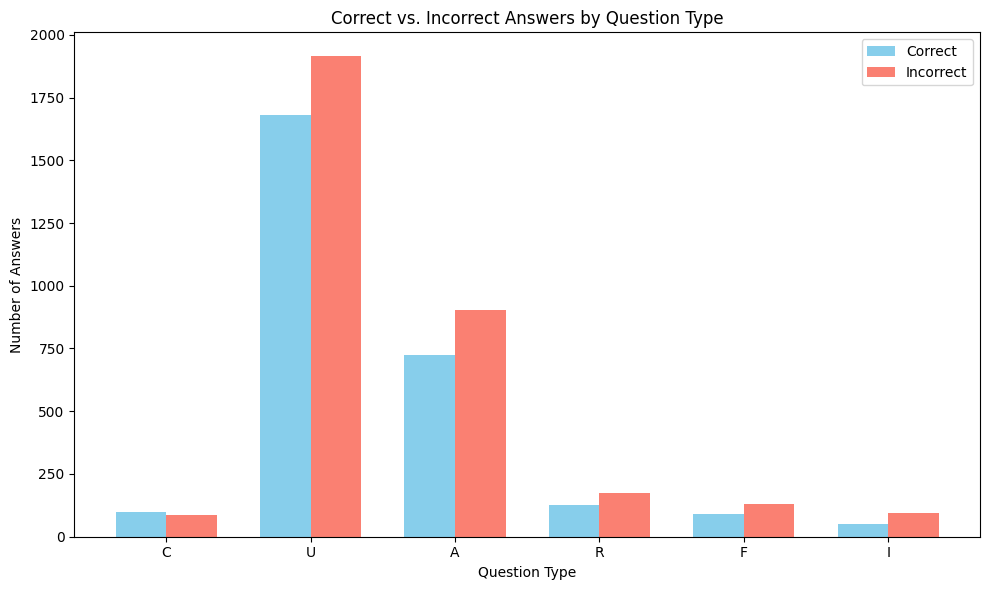

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert the dictionary to a DataFrame for easier plotting
df_performance = pd.DataFrame.from_dict(q_type_performance, orient='index')
df_performance.index.name = 'q_type'

# Calculate accuracy for sorting and summarization
df_performance['total'] = df_performance['correct'] + df_performance['incorrect']
df_performance['accuracy'] = df_performance['correct'] / df_performance['total']

# Sort by accuracy for better visualization and analysis
df_performance = df_performance.sort_values(by='accuracy', ascending=False)

print("Performance by Question Type (sorted by accuracy):")
print(df_performance)

# Plotting the grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(df_performance))

bar1 = ax.bar(index, df_performance['correct'], bar_width, label='Correct', color='skyblue')
bar2 = ax.bar(index + bar_width, df_performance['incorrect'], bar_width, label='Incorrect', color='salmon')

ax.set_xlabel('Question Type')
ax.set_ylabel('Number of Answers')
ax.set_title('Correct vs. Incorrect Answers by Question Type')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(df_performance.index)
ax.legend()

plt.tight_layout()
plt.show()

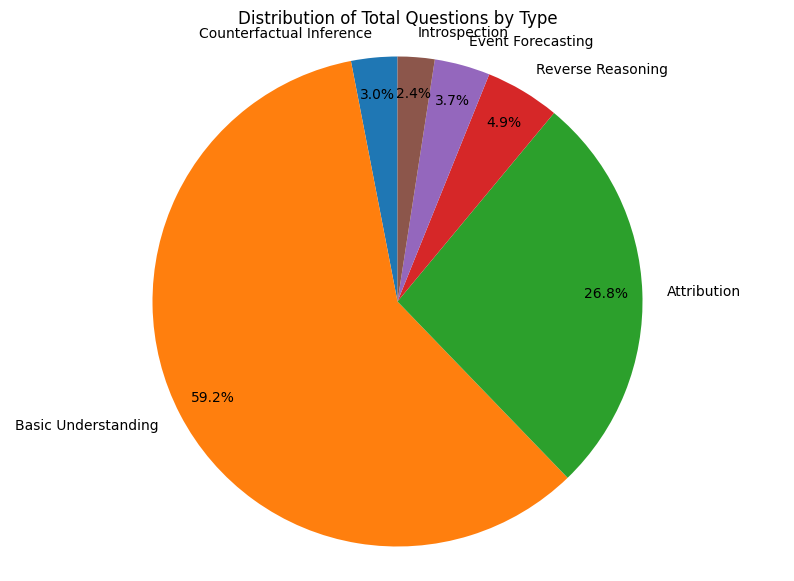

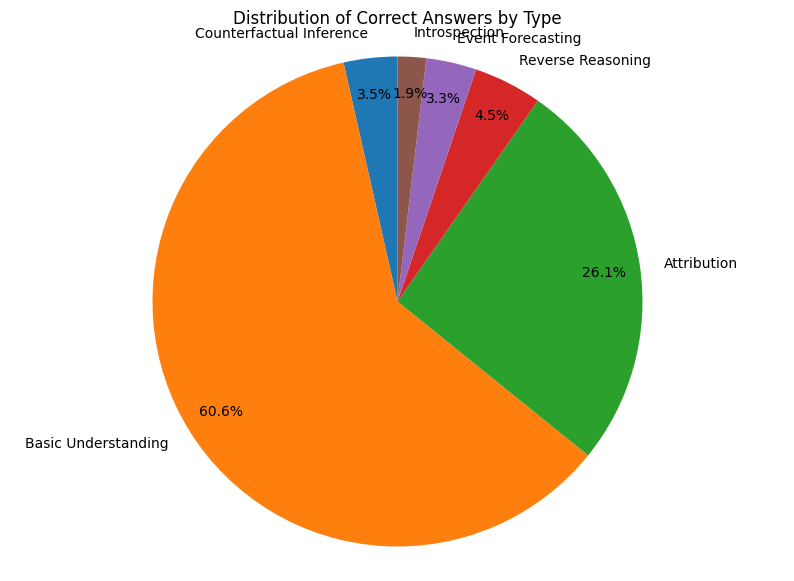

In [ ]:
import matplotlib.pyplot as plt

q_type_labels = {
    "U": "Basic Understanding",
    "A": "Attribution",
    "F": "Event Forecasting",
    "R": "Reverse Reasoning",
    "C": "Counterfactual Inference",
    "I": "Introspection"
}

df_performance['full_q_type'] = df_performance.index.map(q_type_labels)

# Pie chart for Total Questions by Type
plt.figure(figsize=(10, 7))
plt.pie(df_performance['total'], labels=df_performance['full_q_type'], autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Distribution of Total Questions by Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Pie chart for Correct Answers by Type
plt.figure(figsize=(10, 7))
plt.pie(df_performance['correct'], labels=df_performance['full_q_type'], autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Distribution of Correct Answers by Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


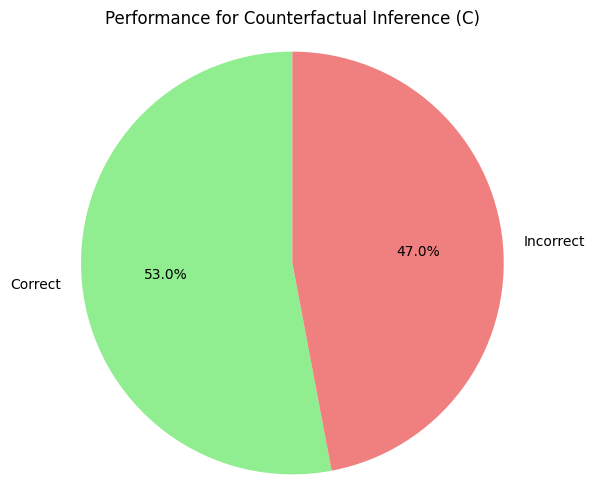

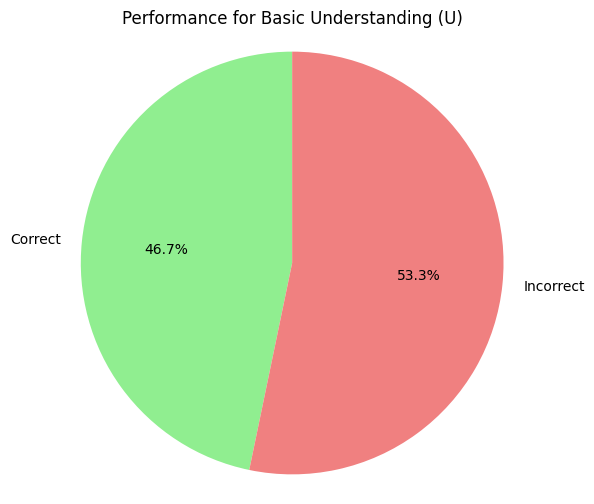

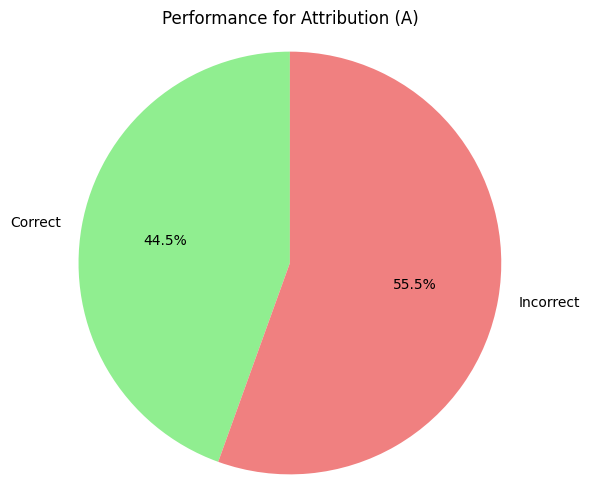

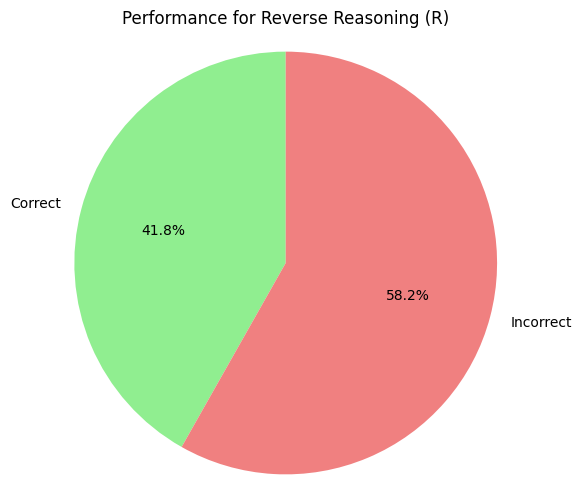

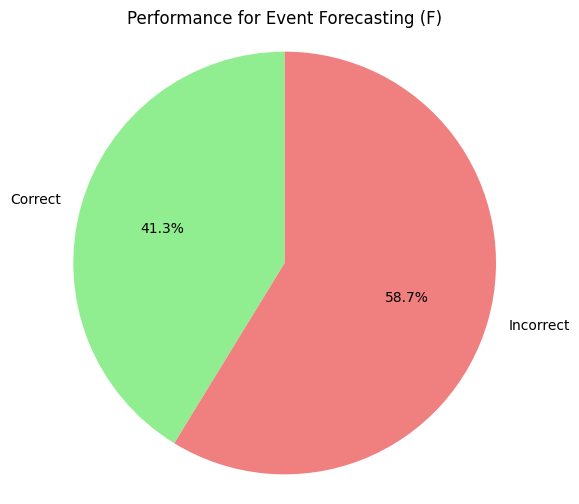

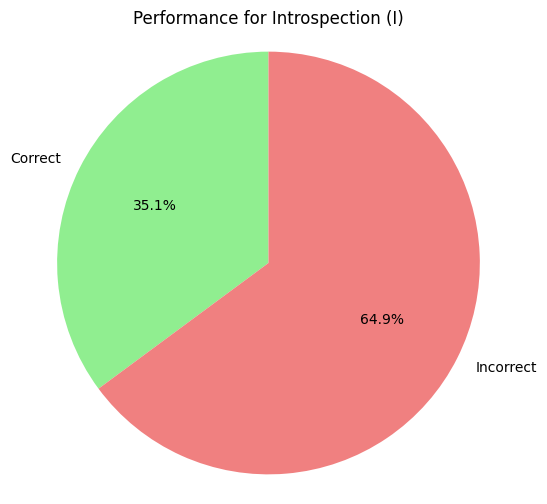

In [ ]:
for index, row in df_performance.iterrows():
    q_type_short = index
    full_q_type_name = row['full_q_type']
    correct_count = row['correct']
    incorrect_count = row['incorrect']

    # Data for the pie chart
    sizes = [correct_count, incorrect_count]
    labels = ['Correct', 'Incorrect']
    colors = ['lightgreen', 'lightcoral']

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'Performance for {full_q_type_name} ({q_type_short})')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

In [ ]:
import pandas as pd

sutd_llava_df = pd.read_csv("/content/sutd_test_with_answers_llava_video_8_frames.csv")
sutd_llava_data = []
for index, row in sutd_llava_df.iterrows():
    id = row["id"]
    answer = row["answer"]
    q_type = None
    for entry in original_data:
        if entry[0] == id:
            q_type = entry[5]
            is_correct = (entry[-1] == answer)
    sutd_llava_data.append({"id": id, "is_correct": is_correct, "q_type": q_type})


In [ ]:
print(sutd_llava_data[0])

{'id': 17732, 'is_correct': True, 'q_type': 'U'}


In [ ]:
llava_q_type_performance = {}

for entry in sutd_llava_data:
    q_type = entry.get('q_type')
    is_correct = entry.get('is_correct')

    if q_type:
        if q_type not in llava_q_type_performance:
            llava_q_type_performance[q_type] = {'correct': 0, 'incorrect': 0}

        if is_correct:
            llava_q_type_performance[q_type]['correct'] += 1
        else:
            llava_q_type_performance[q_type]['incorrect'] += 1

print(llava_q_type_performance)

{'U': {'correct': 1687, 'incorrect': 1907}, 'A': {'correct': 735, 'incorrect': 890}, 'R': {'correct': 125, 'incorrect': 174}, 'F': {'correct': 87, 'incorrect': 136}, 'I': {'correct': 50, 'incorrect': 98}, 'C': {'correct': 77, 'incorrect': 108}}


LLAVA Performance by Question Type (sorted by accuracy):
        correct  incorrect  total  accuracy
q_type                                     
U          1687       1907   3594  0.469393
A           735        890   1625  0.452308
R           125        174    299  0.418060
C            77        108    185  0.416216
F            87        136    223  0.390135
I            50         98    148  0.337838


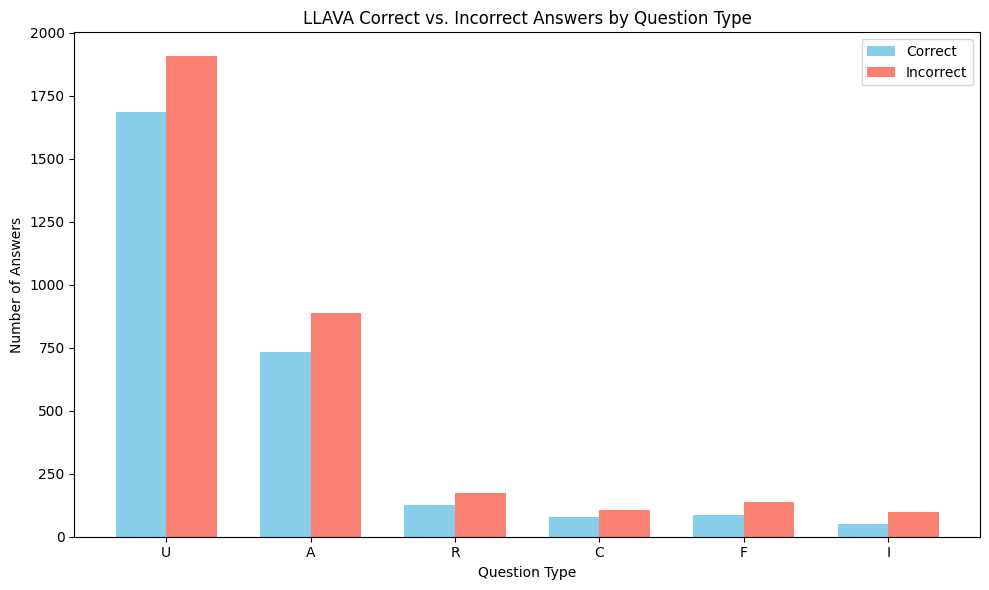

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert the dictionary to a DataFrame for easier plotting
df_llava_performance = pd.DataFrame.from_dict(llava_q_type_performance, orient='index')
df_llava_performance.index.name = 'q_type'

# Calculate total and accuracy for sorting and summarization
df_llava_performance['total'] = df_llava_performance['correct'] + df_llava_performance['incorrect']
df_llava_performance['accuracy'] = df_llava_performance['correct'] / df_llava_performance['total']

# Sort by accuracy for better visualization and analysis
df_llava_performance = df_llava_performance.sort_values(by='accuracy', ascending=False)

print("LLAVA Performance by Question Type (sorted by accuracy):")
print(df_llava_performance)

# Plotting the grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(df_llava_performance))

bar1 = ax.bar(index, df_llava_performance['correct'], bar_width, label='Correct', color='skyblue')
bar2 = ax.bar(index + bar_width, df_llava_performance['incorrect'], bar_width, label='Incorrect', color='salmon')

ax.set_xlabel('Question Type')
ax.set_ylabel('Number of Answers')
ax.set_title('LLAVA Correct vs. Incorrect Answers by Question Type')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(df_llava_performance.index)
ax.legend()

plt.tight_layout()
plt.show()

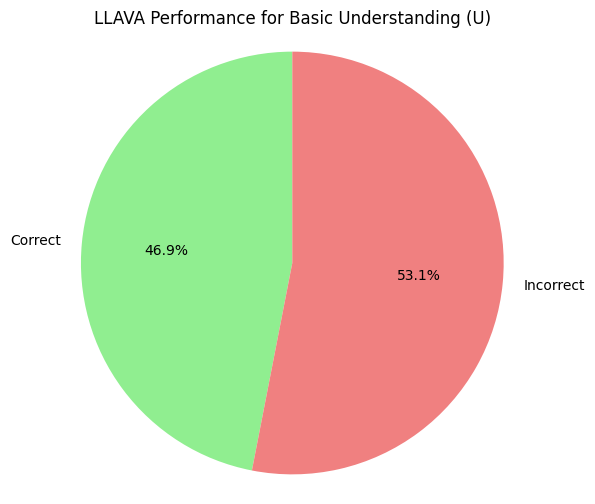

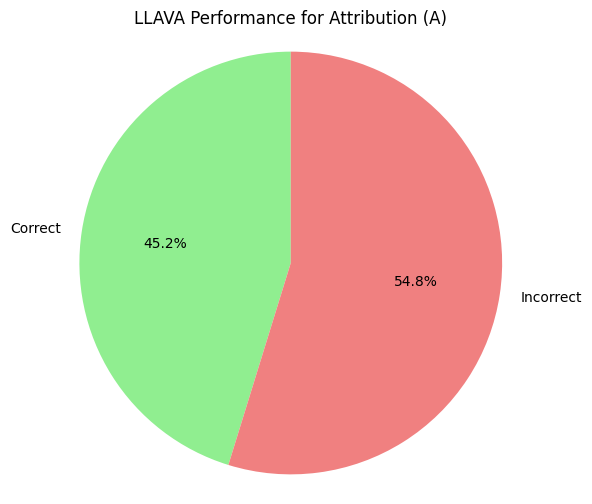

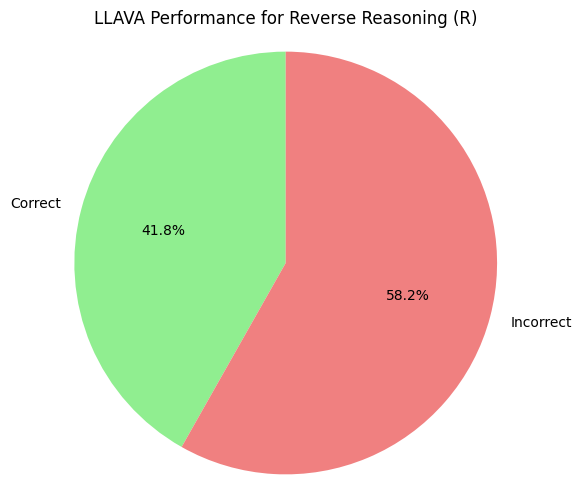

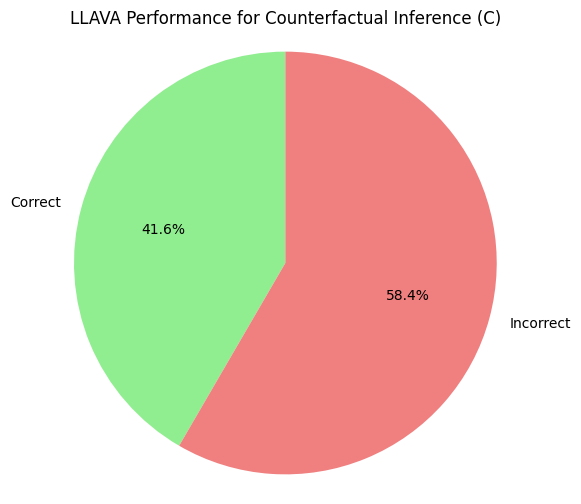

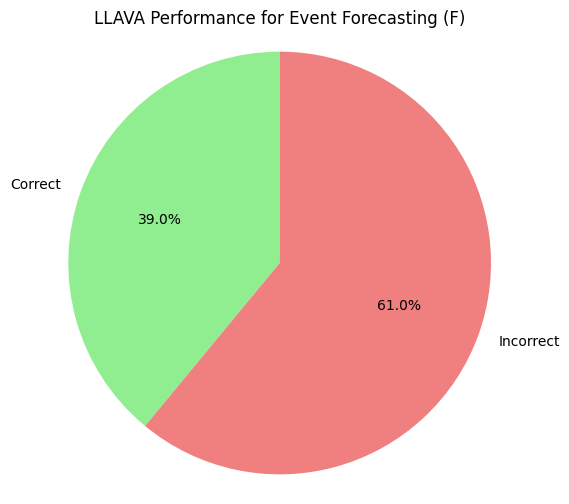

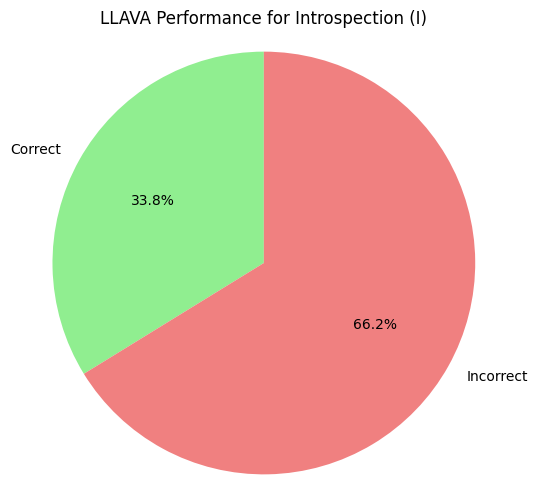

In [ ]:
q_type_labels = {
    "U": "Basic Understanding",
    "A": "Attribution",
    "F": "Event Forecasting",
    "R": "Reverse Reasoning",
    "C": "Counterfactual Inference",
    "I": "Introspection"
}

df_llava_performance['full_q_type'] = df_llava_performance.index.map(q_type_labels)

for index, row in df_llava_performance.iterrows():
    q_type_short = index
    full_q_type_name = row['full_q_type']
    correct_count = row['correct']
    incorrect_count = row['incorrect']

    # Data for the pie chart
    sizes = [correct_count, incorrect_count]
    labels = ['Correct', 'Incorrect']
    colors = ['lightgreen', 'lightcoral']

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'LLAVA Performance for {full_q_type_name} ({q_type_short})')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()